# Design 1: aesthetic_basis time series under a random, ergodic environment

From `literature-notes/main-project-idea.txt`, "Series of Experiments: Design 1": treat `aesthetic_basis` as a time series and ask how it varies over a long exposure horizon, in a random, ergodic environment.

`run_simulation.run_design1()` implements this as: 100 songs, each with a fixed complexity drawn once; 10,000 exposures drawn uniformly at random (with replacement) from that fixed pool (i.i.d. draws → ergodic); `aesthetic_basis` computed on each repeat exposure; a rolling mean over a 20-exposure window as the time-average.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/data/design1_ergodic_timeseries.csv")
df.describe()

,predicted_activation,actual_activation,aesthetic_basis,trial,complexity,aesthetic_basis_rolling_mean
count,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9881.000000
mean,1.602343,0.169891,1.437400,5049.008788,5.070909,1.437050
std,0.472672,0.719338,0.629110,2858.871664,2.717017,0.191214
min,-0.181444,-3.645689,0.001105,8.000000,1.000000,0.927879
25%,1.320156,-0.204948,1.014184,2574.750000,3.000000,1.309465
50%,1.623530,0.252422,1.400662,5049.500000,5.000000,1.409914
75%,1.894273,0.636568,1.818950,7524.250000,7.000000,1.526420
max,3.752710,3.246727,4.590584,9999.000000,10.000000,2.291079


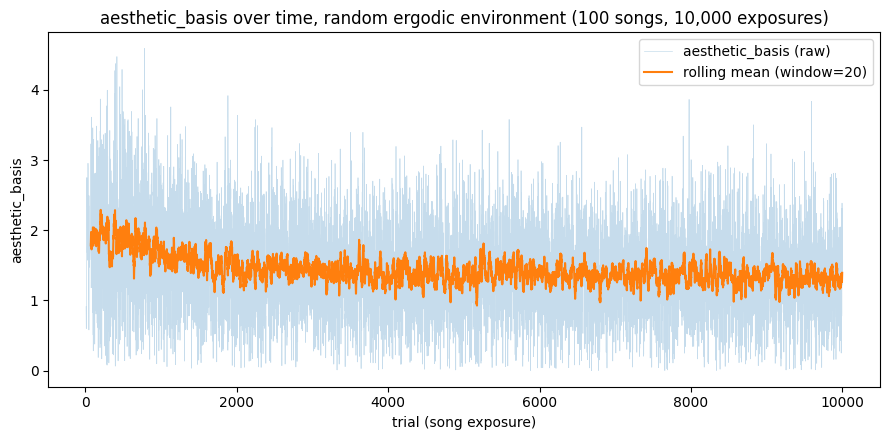

In [2]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["trial"], df["aesthetic_basis"], alpha=0.25, linewidth=0.5, label="aesthetic_basis (raw)")
ax.plot(df["trial"], df["aesthetic_basis_rolling_mean"], linewidth=1.5,
        label="rolling mean (window=20)")
ax.set_xlabel("trial (song exposure)")
ax.set_ylabel("aesthetic_basis")
ax.set_title("aesthetic_basis over time, random ergodic environment (100 songs, 10,000 exposures)")
ax.legend()
fig.tight_layout()
fig.savefig("../results/figures/design1_ergodic_timeseries.png", dpi=150)

If the environment is truly ergodic and the model reaches a steady state, we'd expect the rolling mean to flatten out (stop trending) as more of memory's history accumulates, fluctuating around some fixed level rather than drifting. Check the plot above for whether that's what happens, or whether there's a systematic trend (e.g., rising or falling aesthetic_basis) as songs accumulate more reference history.